<a href="https://colab.research.google.com/github/aishwaryaaramanathan/OTAI_Lab_241501011/blob/main/otai_exp_10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Earliest start times: {'A': 0, 'B': 4.0, 'C': 4.0, 'D': 6.0, 'E': 7.0, 'F': 12.0}
Earliest finish times: {'A': 4.0, 'B': 6.0, 'C': 7.0, 'D': 8.333333333333334, 'E': 12.0, 'F': 15.833333333333334}
Latest start times: {'F': 12.0, 'E': 7.0, 'D': 9.666666666666666, 'C': 4.0, 'B': 7.666666666666666, 'A': 0.0}
Latest finish times: {'A': 4.0, 'B': 9.666666666666666, 'C': 7.0, 'D': 12.0, 'E': 12.0, 'F': 15.833333333333334}
Critical path: ['A', 'C', 'E', 'F']
Project duration (expected): 15.833333333333334
Project standard deviation: 1.4240006242195884


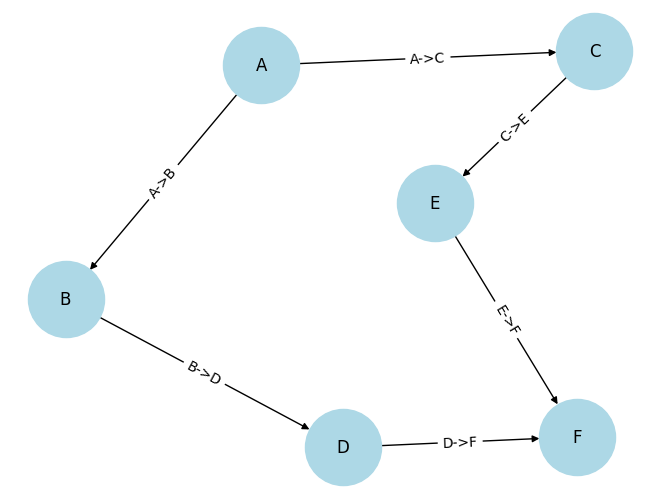

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

# Define tasks
tasks = {
    'A': {'optimistic': 2, 'most_likely': 4, 'pessimistic': 6, 'dependencies': []},
    'B': {'optimistic': 1, 'most_likely': 2, 'pessimistic': 3, 'dependencies': ['A']},
    'C': {'optimistic': 1, 'most_likely': 3, 'pessimistic': 5, 'dependencies': ['A']},
    'D': {'optimistic': 2, 'most_likely': 2, 'pessimistic': 4, 'dependencies': ['B']},
    'E': {'optimistic': 3, 'most_likely': 5, 'pessimistic': 7, 'dependencies': ['C']},
    'F': {'optimistic': 1, 'most_likely': 4, 'pessimistic': 6, 'dependencies': ['D', 'E']}
}

# Step 1: Calculate expected time and variance
for task, data in tasks.items():
    data['duration'] = (
        data['optimistic'] + 4 * data['most_likely'] + data['pessimistic']
    ) / 6
    data['variance'] = ((data['pessimistic'] - data['optimistic']) / 6) ** 2

# Step 2: Create graph
G = nx.DiGraph()
for task, data in tasks.items():
    G.add_node(task, duration=data['duration'], variance=data['variance'])
    for dep in data['dependencies']:
        G.add_edge(dep, task)

# Step 3: Topological order
order = list(nx.topological_sort(G))

# Step 4: Forward pass (ES, EF)
ES = {t: 0 for t in order}
EF = {}

for t in order:
    EF[t] = ES[t] + G.nodes[t]['duration']
    for s in G.successors(t):
        ES[s] = max(ES[s], EF[t])

# Step 5: Backward pass (FIXED)
project_duration = max(EF.values())

LF = {t: project_duration for t in order}
LS = {}

for t in reversed(order):
    LS[t] = LF[t] - G.nodes[t]['duration']
    for p in G.predecessors(t):
        LF[p] = min(LF[p], LS[t])

# Step 6: Critical Path
critical_path = [t for t in order if abs(ES[t] - LS[t]) < 1e-6]

# Step 7: Project variance & std deviation
project_variance = sum(G.nodes[t]['variance'] for t in critical_path)
project_std_dev = np.sqrt(project_variance)

# Step 8: Output
print("Earliest start times:", ES)
print("Earliest finish times:", EF)
print("Latest start times:", LS)
print("Latest finish times:", LF)
print("Critical path:", critical_path)
print("Project duration (expected):", project_duration)
print("Project standard deviation:", project_std_dev)

# Step 9: Plot graph
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=3000, node_color='lightblue')
labels=nx.get_node_attributes(G,'duration')

nx.draw_networkx_edge_labels(
    G, pos,
    edge_labels={(u, v): f"{u}->{v}" for u, v in G.edges}
)

plt.show()